# Gradient Descent Recovery

We consider fixed-step gradient descent for a convex and $L$-smooth function $f$:

$$x_{k+1} = x_k - \frac{1}{L}\nabla f(x_k), \qquad k \ge 0.$$

The reference point $x_\star$ satisfies $\nabla f(x_\star)=0$, and the initial condition is

$$\|x_0-x_\star\| \le R.$$

The performance metric is $f(x_N)-f(x_\star)$. Block 1 numerical evidence below recovers the candidate rate

$$f(x_N)-f(x_\star) \le \frac{L R^2}{4N+2}.$$

## Proof Statement

### Theorem

Let $f$ be convex and $L$-smooth, and let $x_{\star}$ satisfy $\nabla f(x_{\star})=0$. For gradient descent

$$
x_{k+1}=x_k-\frac{1}{L}\nabla f(x_k),
$$

with $\|x_0-x_{\star}\|\le R$, define for $1\le k<N$

$$
V_k = \frac{k+1}{2N-k}\bigl(f(x_k)-f(x_{\star})\bigr)
-\frac{L}{4N+2}\|x_0-x_{\star}\|^2
-\frac{k+1}{2L(2N-k)}\|\nabla f(x_k)\|^2
+\frac{L(2N-2k-1)}{2(2N-k)^2}\|x_{k+1}-x_{\star}\|^2.
$$

The terminal certificate is

$$
V_N=f(x_N)-f(x_{\star})-\frac{L}{4N+2}\|x_0-x_{\star}\|^2.
$$

Then

$$
f(x_N)-f(x_{\star})\le \frac{L R^2}{4N+2}.
$$

### Proof outline

For smooth convex interpolation, use the residual

$$
I_f(u,v)=f(v)-f(u)-\langle \nabla f(u),v-u\rangle-\frac{1}{2L}\|\nabla f(v)-\nabla f(u)\|^2\le 0.
$$

Let

$$
\lambda_{k,k+1}=\frac{k+1}{2N-k},\qquad
\lambda_{\star,k+1}=\frac{k+2}{2N-k-1}-\frac{k+1}{2N-k},
$$

and

$$
\sigma_k=\frac{4Nk+6N-2k^2-4k-1}{2(2N-k-1)^2}.
$$

For $1\le k<N-1$, the one-step identity is

$$
V_{k+1}-V_k = \lambda_{k,k+1} I_f(x_k,x_{k+1})
+\lambda_{\star,k+1} I_f(x_{\star},x_{k+1})
-L\sigma_k\left\|\frac{x_{k+1}-x_{\star}}{2N-k}-\frac{1}{L}\nabla f(x_{k+1})\right\|^2\le 0.
$$

The base identity is

$$
V_1=\lambda_{\star,0}I_f(x_{\star},x_0)+\lambda_{0,1}I_f(x_0,x_1)
+\lambda_{\star,1}I_f(x_{\star},x_1)-L\delta_0\|z_0\|^2
-L\sigma_0\left\|\frac{x_1-x_{\star}}{2N}-\frac{1}{L}\nabla f(x_1)\right\|^2\le 0,
$$

where $\lambda_{\star,0}=\lambda_{0,1}=1/(2N)$, $\delta_0=(2N+1)/(8N^2)$, and

$$
z_0=\frac{x_0-x_{\star}}{2N+1}-\frac{1}{L}\nabla f(x_0).
$$

Thus the Lyapunov sequence is nonincreasing and $V_N\le 0$. The boundary identity gives

$$
V_N=f(x_N)-f(x_{\star})-\frac{L}{4N+2}\|x_0-x_{\star}\|^2,
$$

so $f(x_N)-f(x_{\star})\le L\|x_0-x_{\star}\|^2/(4N+2)\le LR^2/(4N+2)$.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import sympy as sp

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pepflow as pf  # noqa: E402

In [2]:
L = pf.Parameter("L")
R = pf.Parameter("R")
f = pf.SmoothConvexFunction(is_basis=True, tags=["f"], L=L)

In [3]:
def make_ctx_gd_recover(ctx_name: str, N, **kwargs) -> pf.PEPContext:
    """Build the PEPContext encoding N steps of fixed-step gradient descent."""
    ctx = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])
    f.set_stationary_point("x_star")

    for k in range(int(N)):
        x = x - (sp.S(1) / L) * f.grad(x)
        x.add_tag(f"x_{k + 1}")

    return ctx


def get_pep_setup(N, params):
    """Standard interface for pep_runner.py."""
    ctx = make_ctx_gd_recover(f"ctx_{N}", N)
    pb = pf.PEPBuilder(ctx)
    pb.add_initial_constraint(
        ((ctx["x_0"] - ctx["x_star"]) ** 2).le(R**2, name="initial_condition")
    )
    pb.set_performance_metric(f(ctx[f"x_{N}"]) - f(ctx["x_star"]))
    return ctx, pb, f

N  PEP value     candidate
1  0.16666647   0.16666667
2  0.09999779   0.10000000
3  0.07142958   0.07142857
4  0.05555563   0.05555556
5  0.04545414   0.04545455
6  0.03846168   0.03846154
7  0.03333328   0.03333333


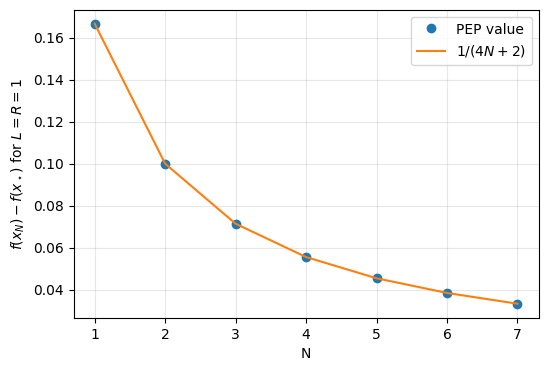

In [4]:
state_path = ROOT / "examples_peppy" / "gd_recover" / "state" / "gd_recover_b1.json"
state = json.loads(state_path.read_text())
rows = [
    (r["N"], float(r["opt_value"]), 1.0 / (4 * r["N"] + 2))
    for r in state["sweep_results"]
]

print("N  PEP value     candidate")
for N, opt, candidate in rows:
    print(f"{N:<2d} {opt:.8f}   {candidate:.8f}")

Ns = [N for N, _, _ in rows]
opts = [opt for _, opt, _ in rows]
candidates = [candidate for _, _, candidate in rows]

plt.figure(figsize=(6, 4))
plt.plot(Ns, opts, "o", label="PEP value")
plt.plot(Ns, candidates, "-", label=r"$1/(4N+2)$")
plt.xlabel("N")
plt.ylabel(r"$f(x_N)-f(x_\star)$ for $L=R=1$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Dense And Relaxed Proof Solves

For Block 2 we solve the full PEP at `N=4`, then impose a sparse relaxation that keeps only the consecutive interpolation inequalities and the star-row inequalities. The relaxed solve preserves the objective value at the recovered rate.

In [5]:
b2_path = ROOT / "examples_peppy" / "gd_recover" / "state" / "gd_recover_b2.json"
dense_path = ROOT / "examples_peppy" / "gd_recover" / "state" / "gd_recover_dense.json"
relaxed_path = (
    ROOT / "examples_peppy" / "gd_recover" / "state" / "gd_recover_relaxed.json"
)

b2 = json.loads(b2_path.read_text())
dense = json.loads(dense_path.read_text())
relaxed = json.loads(relaxed_path.read_text())

N_int = b2["N_verify"]
candidate = 1 / (4 * N_int + 2)
print(f"N_verify: {N_int}")
print(f"dense objective:   {dense['opt_value']:.10f}")
print(f"relaxed objective: {relaxed['opt_value']:.10f}")
print(f"candidate rate:    {candidate:.10f}")
print(f"preserved:         {abs(dense['opt_value'] - relaxed['opt_value']) < 1e-5}")
print()
print("Active interpolation constraints:")
for name in b2["active_constraints"]:
    print(" ", name)

N_verify: 4
dense objective:   0.0555556260
relaxed objective: 0.0555555483
candidate rate:    0.0555555556
preserved:         True

Active interpolation constraints:
  f:x_0,x_1
  f:x_1,x_2
  f:x_2,x_3
  f:x_3,x_4
  f:x_star,x_0
  f:x_star,x_1
  f:x_star,x_2
  f:x_star,x_3
  f:x_star,x_4
  f:x_star,x_star


## Closed-Form Lambda Certificate

The active interpolation multipliers are

$$
\lambda_{i,i+1}=\frac{i+1}{2N-i},\qquad i=0,\ldots,N-1,
$$

with the star-row multipliers given by the telescoping differences

$$
\lambda_{\star,0}=\lambda_{0,1},\qquad
\lambda_{\star,j}=\lambda_{j,j+1}-\lambda_{j-1,j}\ (1\le j<N),\qquad
\lambda_{\star,N}=1-\lambda_{N-1,N}.
$$

In [6]:
import numpy as np
import itertools


def tag_to_index(tag, N=N_int):
    return N + 1 if tag == "x_star" else int(tag.split("_")[1])


def lamb(ri, ci, N=N_int):
    i = tag_to_index(ri, N)
    j = tag_to_index(ci, N)
    if i == N + 1:
        if j == 0:
            return lamb("x_0", "x_1", N)
        if j < N:
            return lamb(f"x_{j}", f"x_{j + 1}", N) - lamb(f"x_{j - 1}", f"x_{j}", N)
        if j == N:
            return sp.Rational(1, 1) - lamb(f"x_{N - 1}", f"x_{N}", N)
    if i < N and i + 1 == j:
        return sp.Rational(j, 2 * N + 1 - j)
    return sp.S(0)


rows = b2["lambda_row_names"]
cols = b2["lambda_col_names"]
lamb_cand = np.array([[lamb(ri, ci) for ci in cols] for ri in rows], dtype=object)
lamb_sol = np.array(b2["lambda_matrix"], dtype=float)

print(
    "max lambda residual:", np.max(np.abs(np.array(lamb_cand, dtype=float) - lamb_sol))
)
pf.pprint_labeled_matrix(lamb_cand, rows, cols, precision=None)

max lambda residual: 6.257644294405118e-08


<IPython.core.display.Math object>

## S Decomposition

At `N=4`, the relaxed dual matrix is represented as a positive combination of five squares:

$$
S = L\sum_{i=0}^{N}\delta_i
\left\|\frac{x_i-x_\star}{2N+1-i}-\frac{1}{L}\nabla f(x_i)\right\|^2,
$$

with

$$
(\delta_0,\delta_1,\delta_2,\delta_3,\delta_4)
=\left(\frac{9}{128},\frac{23}{98},\frac{11}{24},\frac{39}{50},\frac{1}{2}\right).
$$

In [7]:
N = sp.S(N_int)
params_sp = {"L": sp.S(1), "R": sp.S(1)}
ctx_prf, pb_prf, f_prf = get_pep_setup(N, params_sp)
pm = pf.ExpressionManager(ctx_prf, resolve_parameters=params_sp)

x = [ctx_prf[f"x_{i}"] for i in range(N_int + 1)]
x_0 = ctx_prf["x_0"]
x_star = ctx_prf["x_star"]
x_N = ctx_prf[f"x_{N_int}"]

delta = [
    sp.Rational(9, 128),
    sp.Rational(23, 98),
    sp.Rational(11, 24),
    sp.Rational(39, 50),
    sp.Rational(1, 2),
]
S_guess = pf.Scalar.zero()
for i, coeff_i in enumerate(delta):
    z_i = (x[i] - x_star) / sp.S(2 * N_int + 1 - i) - (sp.S(1) / L) * f_prf.grad(x[i])
    S_guess += L * coeff_i * z_i**2

S_guess_np = pm.eval_scalar(S_guess).inner_prod_coords
S_sol_np = np.array(b2["S_matrix"], dtype=float)
print("S numerical rank:", b2["S_rank_tol_1e-7"])
print("max S residual:", np.max(np.abs(S_guess_np - S_sol_np)))
pf.pprint_labeled_matrix(S_guess_np, b2["S_row_names"], b2["S_col_names"])

S numerical rank: 5
max S residual: 6.27516850704168e-8


<IPython.core.display.Math object>

## Full Proof Identity

The fixed-`N` certificate verifies

$$
f(x_N)-f(x_\star)-\frac{1}{4N+2}\|x_0-x_\star\|^2
-\sum_{i,j}\lambda_{i,j} I_f(x_i,x_j) + S = 0.
$$

In [8]:
interp_sum = pf.Scalar.zero()
for ri, ci in itertools.product(rows, cols):
    c = lamb(ri, ci)
    if c != 0:
        interp_sum += c * f_prf.interp_ineq(ri, ci)

tau = sp.Rational(1, 4 * N_int + 2)
lhs = f_prf(x_N) - f_prf(x_star) - tau * (x_0 - x_star) ** 2
proof_residual = lhs - interp_sum + S_guess
proof_residual_np = pm.eval_scalar(proof_residual).inner_prod_coords

print("proof valid:", np.allclose(proof_residual_np, 0, atol=1e-10))
print("max proof residual:", np.max(np.abs(proof_residual_np)))
pf.pprint_labeled_matrix(proof_residual_np, b2["S_row_names"], b2["S_col_names"])

proof valid: True
max proof residual: 5.55111512312578e-17


<IPython.core.display.Math object>

## Lyapunov Partial-Sum Construction

The sparse certificate can be accumulated step by step. With the smooth-convex interpolation residuals $I_f(u,v)\le 0$, define the increments by

$$
V_{k+1}-V_k
= \lambda_{k,k+1} I_f(x_k,x_{k+1})
+ \lambda_{\star,k+1} I_f(x_\star,x_{k+1})
- L\delta_{k+1}\left\|\frac{x_{k+1}-x_\star}{2N-k}-\frac{1}{L}\nabla f(x_{k+1})\right\|^2.
$$

The initial boundary contribution is

$$
-L\delta_0\left\|\frac{x_0-x_\star}{2N+1}-\frac{1}{L}\nabla f(x_0)\right\|^2
+\lambda_{\star,0}I_f(x_\star,x_0).
$$

This sign convention gives the nonincreasing Lyapunov direction. The interior ranks should be constant; the final rank-one term is the boundary coverage residual.

In [9]:
b3_path = ROOT / "examples_peppy" / "gd_recover" / "state" / "gd_recover_b3.json"
b3 = json.loads(b3_path.read_text())

print("Nonzero interpolation duals:")
for ri in b3["lambda_row_names"]:
    for ci in b3["lambda_col_names"]:
        value = lamb(ri, ci)
        if value != 0:
            print(f"  lambda({ri}, {ci}) = {value}")

print("Extra constraint duals:", b3["extra_duals"])

Nonzero interpolation duals:
  lambda(x_0, x_1) = 1/8
  lambda(x_1, x_2) = 2/7
  lambda(x_2, x_3) = 1/2
  lambda(x_3, x_4) = 4/5
  lambda(x_star, x_0) = 1/8
  lambda(x_star, x_1) = 9/56
  lambda(x_star, x_2) = 3/14
  lambda(x_star, x_3) = 3/10
  lambda(x_star, x_4) = 1/5
Extra constraint duals: {}


In [10]:
N = sp.S(N_int)
params_sp = {"L": sp.S(1), "R": sp.S(1)}
ctx_lyap, pb_lyap, obj = get_pep_setup(N, params_sp)
pm = pf.ExpressionManager(ctx_lyap, resolve_parameters=params_sp)

x = [ctx_lyap[f"x_{i}"] for i in range(N_int + 1)]
x_star = ctx_lyap["x_star"]
L = globals()["L"]

delta = [
    sp.Rational(9, 128),
    sp.Rational(23, 98),
    sp.Rational(11, 24),
    sp.Rational(39, 50),
    sp.Rational(1, 2),
]
z = [
    (x[i] - x_star) / sp.S(2 * N_int + 1 - i) - (sp.S(1) / L) * obj.grad(x[i])
    for i in range(N_int + 1)
]

lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
partial_sum -= L * delta[0] * z[0] ** 2
partial_sum += lamb("x_star", "x_0") * obj.interp_ineq("x_star", "x_0")

for step in range(N_int):
    partial_sum += lamb(f"x_{step}", f"x_{step + 1}") * obj.interp_ineq(
        f"x_{step}", f"x_{step + 1}"
    )
    partial_sum += lamb("x_star", f"x_{step + 1}") * obj.interp_ineq(
        "x_star", f"x_{step + 1}"
    )
    partial_sum -= L * delta[step + 1] * z[step + 1] ** 2
    lyap.append(partial_sum)

rank_tolerance = 1e-4
ranks = []
for k, Vk in enumerate(lyap):
    matrix = pm.eval_scalar(Vk).inner_prod_coords.astype(float)
    rank = int(np.linalg.matrix_rank(matrix, tol=rank_tolerance))
    ranks.append(rank)
    print(f"rank V_{k}: {rank}")
    if k == 0:
        print()

print("Interior rank is constant:", len(set(ranks[1:N_int])) == 1)

rank V_0: 0

rank V_1: 3
rank V_2: 3
rank V_3: 3
rank V_4: 1
Interior rank is constant: True


c:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\pep_context.py:172: UserWarning:

The provided name was already used. The older PEPContext will be overwritten. PEPBuilders constructed with the older PEPContext should be remade.



In [11]:
M_final = pm.eval_scalar(lyap[N_int]).inner_prod_coords.astype(float)
rank_final = int(np.linalg.matrix_rank(M_final, tol=rank_tolerance))

tau = sp.Rational(1, 4 * N_int + 2)
boundary = obj(x[N_int]) - obj(x_star) - tau * (x[0] - x_star) ** 2
coverage_residual = lyap[N_int] - boundary
coverage_matrix = pm.eval_scalar(coverage_residual).inner_prod_coords.astype(float)
coverage_func = pm.eval_scalar(coverage_residual).func_coords.astype(float)

print(f"lyap[{N_int}] rank:", rank_final)
print("coverage residual matrix max abs:", np.max(np.abs(coverage_matrix)))
print("coverage residual func max abs:", np.max(np.abs(coverage_func)))
print("Coverage check: lyap[N] rank should be 0 or 1 (boundary identity term)")

lyap[4] rank: 1
coverage residual matrix max abs: 2.7755575615628914e-17
coverage residual func max abs: 0.0
Coverage check: lyap[N] rank should be 0 or 1 (boundary identity term)


## Identify the vectors composing the Lyapunov function

Block 4 starts from the Block 3 partial sums and searches for interpretable rank-spanning vectors. The goal is to express each interior $V_k$ in a stable three-vector basis, then read off the coefficient pattern in $k$ and $N$.

In [12]:
from itertools import combinations
from pepflow.lyapunov_utils import (
    find_symmetric_coefficient_matrix,
    vectors_in_column_space,
)

b4_path = ROOT / "examples_peppy" / "gd_recover" / "state" / "gd_recover_b4.json"
b4 = json.loads(b4_path.read_text())

rebuilt_ranks = []
for Vk in lyap:
    matrix = pm.eval_scalar(Vk).inner_prod_coords.astype(float)
    rebuilt_ranks.append(int(np.linalg.matrix_rank(matrix, tol=rank_tolerance)))

print("Stored rank profile: ", b4["rank_profile"])
print("Rebuilt rank profile:", rebuilt_ranks)

Stored rank profile:  [0, 3, 3, 3, 1]
Rebuilt rank profile: [0, 3, 3, 3, 1]


### Candidate-vector scan

The candidate family includes tagged iterates, gradients, point-to-solution gaps, and pairwise differences. Duplicate and zero evaluated vectors are removed before the column-space scan.

In [13]:
def add_candidate(candidates, label, vector):
    coords = np.asarray(pm.eval_vector(vector).coords, dtype=float).ravel()
    if np.linalg.norm(coords) < 1e-10:
        return
    for _, _, old_coords in candidates:
        if np.allclose(coords, old_coords, atol=1e-10, rtol=1e-10):
            return
    candidates.append((label, vector, coords))


candidates = []
for i in range(N_int + 1):
    add_candidate(candidates, f"x_{i}", ctx_lyap[f"x_{i}"])
add_candidate(candidates, "x_star", x_star)
for i in range(N_int + 1):
    add_candidate(candidates, f"g_{i}", obj.grad(ctx_lyap[f"x_{i}"]))
for i in range(N_int + 1):
    add_candidate(candidates, f"x_{i}-x_star", ctx_lyap[f"x_{i}"] - x_star)

base_candidates = list(candidates)
for (label_i, vec_i, _), (label_j, vec_j, _) in combinations(base_candidates, 2):
    add_candidate(candidates, f"{label_i} - {label_j}", vec_i - vec_j)

candidate_labels = [label for label, _, _ in candidates]
candidate_vectors = [vector for _, vector, _ in candidates]
print("candidate count:", len(candidates))

candidate count: 104


In [14]:
for k in range(1, N_int):
    in_col = vectors_in_column_space(
        lyap[k],
        candidate_vectors,
        pep_context=ctx_lyap,
        resolve_parameters=params_sp,
        rtol=1e-4,
        atol=1e-4,
    )
    print(f"V_{k} column-space candidates:")
    for vec in in_col:
        print("  ", candidate_labels[candidate_vectors.index(vec)])
    print()

V_1 column-space candidates:
   g_0
   g_1
   x_0-x_star
   x_1-x_star
   x_2-x_star
   x_0 - x_2
   g_0 - g_1
   g_0 - x_0-x_star
   g_0 - x_1-x_star
   g_0 - x_2-x_star
   g_1 - x_0-x_star
   g_1 - x_1-x_star
   g_1 - x_2-x_star

V_2 column-space candidates:
   g_2
   x_0-x_star
   x_2-x_star
   x_3-x_star
   x_0 - x_2
   x_0 - x_3
   g_1 - x_1-x_star
   g_2 - x_0-x_star
   g_2 - x_2-x_star
   g_2 - x_3-x_star

V_3 column-space candidates:
   g_3
   x_0-x_star
   x_3-x_star
   x_4-x_star
   x_0 - x_3
   x_0 - x_4
   g_2 - x_2-x_star
   g_3 - x_0-x_star
   g_3 - x_3-x_star
   g_3 - x_4-x_star



### Selected basis pattern

The scan identifies the interior template

$$
\mathcal B_k = \left[x_0-x_\star,\ \nabla f(x_k),\ x_{k+1}-x_\star\right],
\qquad 1\le k<N,
$$

and the terminal boundary case

$$
\mathcal B_N = \left[x_0-x_\star\right].
$$

In [15]:
def V_k_basis(k):
    if k == N_int:
        return [ctx_lyap["x_0"] - ctx_lyap["x_star"]]
    return [
        ctx_lyap["x_0"] - ctx_lyap["x_star"],
        obj.grad(ctx_lyap[f"x_{k}"]),
        ctx_lyap[f"x_{k + 1}"] - ctx_lyap["x_star"],
    ]


def V_k_basis_labels(k):
    if k == N_int:
        return ["x_0 - x_star"]
    return ["x_0 - x_star", f"grad_f(x_{k})", f"x_{k + 1} - x_star"]


for k in range(1, N_int + 1):
    basis = V_k_basis(k)
    coords = np.column_stack(
        [pm.eval_vector(v).coords.astype(float).ravel() for v in basis]
    )
    basis_rank = int(np.linalg.matrix_rank(coords, tol=1e-7))
    print(f"k={k}: rank {basis_rank} basis {V_k_basis_labels(k)}")

k=1: rank 3 basis ['x_0 - x_star', 'grad_f(x_1)', 'x_2 - x_star']
k=2: rank 3 basis ['x_0 - x_star', 'grad_f(x_2)', 'x_3 - x_star']
k=3: rank 3 basis ['x_0 - x_star', 'grad_f(x_3)', 'x_4 - x_star']
k=4: rank 1 basis ['x_0 - x_star']


### Coefficient matrices

For $1\le k<N$, the basis order is $[x_0-x_\star, \nabla f(x_k), x_{k+1}-x_\star]$. At $k=N$, the basis is $[x_0-x_\star]$.

In [16]:
def coeff_pattern(k, N):
    if k == N:
        return {(0, 0): -sp.Rational(1, 4 * N + 2)}, {"f(x_N)-f(x_star)": sp.S(1)}
    return {
        (0, 0): -sp.Rational(1, 4 * N + 2),
        (1, 1): -sp.Rational(k + 1, 2 * (2 * N - k)),
        (2, 2): sp.Rational(2 * N - 2 * k - 1, 2 * (2 * N - k) ** 2),
    }, {f"f(x_{k})-f(x_star)": sp.Rational(k + 1, 2 * N - k)}


for k in range(1, N_int + 1):
    basis = V_k_basis(k)
    labels = V_k_basis_labels(k)
    C = find_symmetric_coefficient_matrix(
        lyap[k],
        basis,
        pep_context=ctx_lyap,
        resolve_parameters=params_sp,
    )
    pattern, function_pattern = coeff_pattern(k, N_int)
    C_pattern = np.zeros_like(C)
    for (i, j), value in pattern.items():
        C_pattern[i, j] = float(value)
        C_pattern[j, i] = float(value)

    print(f"k={k}: formula residual {np.max(np.abs(C - C_pattern)):.2e}")
    print("function part:", function_pattern)
    pf.pprint_labeled_matrix(C, labels, labels, precision=None)

k=1: formula residual 7.63e-17
function part: {'f(x_1)-f(x_star)': 2/7}


<IPython.core.display.Math object>

k=2: formula residual 1.94e-16
function part: {'f(x_2)-f(x_star)': 1/2}


<IPython.core.display.Math object>

k=3: formula residual 2.22e-16
function part: {'f(x_3)-f(x_star)': 4/5}


<IPython.core.display.Math object>

k=4: formula residual 0.00e+00
function part: {'f(x_N)-f(x_star)': 1}


<IPython.core.display.Math object>

### Block 4 conclusion

The current closed-form candidate is

$$
V_k =
\frac{k+1}{2N-k}\bigl(f(x_k)-f(x_\star)\bigr)
-\frac{1}{4N+2}\|x_0-x_\star\|^2
-\frac{k+1}{2(2N-k)}\|\nabla f(x_k)\|^2
+\frac{2N-2k-1}{2(2N-k)^2}\|x_{k+1}-x_\star\|^2,
$$

for $1\le k<N$, with terminal boundary

$$
V_N=f(x_N)-f(x_\star)-\frac{1}{4N+2}\|x_0-x_\star\|^2.
$$

Block 5 will symbolically verify the base, step, and boundary identities.

## Coefficient Extraction and Closed-Form $V_k$

The coefficient extraction in Block 4 gives the closed form used in the theorem. The next sections verify the one-step recursion, the base identity, and the boundary identity symbolically using PEPFlow expressions.

## Symbolic Step Recursion Verification

For $1\le k<N-1$, verify

$$
V_{k+1}-V_k = \lambda_{k,k+1} I_f(x_k,x_{k+1})
+\lambda_{\star,k+1} I_f(x_{\star},x_{k+1})
-L\sigma_k\left\|\frac{x_{k+1}-x_{\star}}{2N-k}-\frac{1}{L}\nabla f(x_{k+1})\right\|^2.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [17]:
ctx_step = pf.PEPContext("gd_step_symbolic").set_as_current()
L_step = pf.Parameter("L")
k_step = pf.Parameter("k")
N_step = pf.Parameter("N")
f_step = pf.SmoothConvexFunction(is_basis=True, tags=["f_step"], L=L_step)
f_step.set_stationary_point("x_star")
xs_step = ctx_step["x_star"]
x0_step = pf.Vector(is_basis=True, tags=["x_0"])
xk_step = pf.Vector(is_basis=True, tags=["x_k"])
xk1_step = xk_step - (1 / L_step) * f_step.grad(xk_step)
xk1_step.add_tag("x_{k+1}")
xk2_step = xk1_step - (1 / L_step) * f_step.grad(xk1_step)
xk2_step.add_tag("x_{k+2}")


def a_step(t):
    return (t + 1) / (2 * N_step - t)


def b_step(t):
    return -(t + 1) / (2 * L_step * (2 * N_step - t))


def c_step(t):
    return L_step * (2 * N_step - 2 * t - 1) / (2 * (2 * N_step - t) ** 2)


d_step = -L_step / (4 * N_step + 2)
V_k_step = (
    a_step(k_step) * (f_step(xk_step) - f_step(xs_step))
    + b_step(k_step) * f_step.grad(xk_step) ** 2
    + c_step(k_step) * (xk1_step - xs_step) ** 2
    + d_step * (x0_step - xs_step) ** 2
)
V_k1_step = (
    a_step(k_step + 1) * (f_step(xk1_step) - f_step(xs_step))
    + b_step(k_step + 1) * f_step.grad(xk1_step) ** 2
    + c_step(k_step + 1) * (xk2_step - xs_step) ** 2
    + d_step * (x0_step - xs_step) ** 2
)
lambda_consecutive = (k_step + 1) / (2 * N_step - k_step)
lambda_star_next = (k_step + 2) / (2 * N_step - k_step - 1) - lambda_consecutive
sigma_step = (4 * N_step * k_step + 6 * N_step - 2 * k_step**2 - 4 * k_step - 1) / (
    2 * (2 * N_step - k_step - 1) ** 2
)
z_step = (xk1_step - xs_step) / (2 * N_step - k_step) - (1 / L_step) * f_step.grad(
    xk1_step
)
LHS_step = V_k1_step - V_k_step
RHS_step = (
    lambda_consecutive * f_step.interp_ineq("x_k", "x_{k+1}")
    + lambda_star_next * f_step.interp_ineq("x_star", "x_{k+1}")
    - L_step * sigma_step * z_step**2
)
diff_step = LHS_step - RHS_step
k_sp, N_sp, L_sp = sp.symbols("k N L", positive=True)
pm_step = pf.ExpressionManager(
    ctx_step, resolve_parameters={"k": k_sp, "N": N_sp, "L": L_sp}
)
step_matrix = sp.Matrix(pm_step.eval_scalar(diff_step).inner_prod_coords).applyfunc(
    lambda e: sp.simplify(sp.nsimplify(e))
)
step_funcs = sp.Matrix(pm_step.eval_scalar(diff_step).func_coords).applyfunc(
    lambda e: sp.simplify(sp.nsimplify(e))
)
pf.pprint_labeled_matrix(
    np.array(step_matrix.tolist(), dtype=object),
    [str(v) for v in ctx_step.basis_vectors()],
    [str(v) for v in ctx_step.basis_vectors()],
    precision=None,
)
pf.pprint_labeled_vector(
    np.array(step_funcs, dtype=object).reshape(-1),
    [str(v) for v in ctx_step.basis_scalars()],
    precision=None,
)
print(
    "Step identity zero:",
    step_matrix == sp.zeros(*step_matrix.shape)
    and step_funcs == sp.zeros(*step_funcs.shape),
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Step identity zero: True


## Base Case Symbolic Verification

Verify

$$
V_1=\lambda_{\star,0}I_f(x_{\star},x_0)+\lambda_{0,1}I_f(x_0,x_1)
+\lambda_{\star,1}I_f(x_{\star},x_1)-L\delta_0\|z_0\|^2
-L\sigma_0\left\|\frac{x_1-x_{\star}}{2N}-\frac{1}{L}\nabla f(x_1)\right\|^2.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [18]:
ctx_base = pf.PEPContext("gd_base_symbolic").set_as_current()
L_base = pf.Parameter("L")
N_base = pf.Parameter("N")
f_base = pf.SmoothConvexFunction(is_basis=True, tags=["f_base"], L=L_base)
f_base.set_stationary_point("x_star")
xs_base = ctx_base["x_star"]
x0_base = pf.Vector(is_basis=True, tags=["x_0"])
x1_base = x0_base - (1 / L_base) * f_base.grad(x0_base)
x1_base.add_tag("x_1")
x2_base = x1_base - (1 / L_base) * f_base.grad(x1_base)
x2_base.add_tag("x_2")
V1_base = (
    sp.S(2) / (2 * N_base - 1) * (f_base(x1_base) - f_base(xs_base))
    - sp.S(1) / (L_base * (2 * N_base - 1)) * f_base.grad(x1_base) ** 2
    + L_base * (2 * N_base - 3) / (2 * (2 * N_base - 1) ** 2) * (x2_base - xs_base) ** 2
    - L_base / (4 * N_base + 2) * (x0_base - xs_base) ** 2
)
lambda_star0 = sp.S(1) / (2 * N_base)
lambda_01 = sp.S(1) / (2 * N_base)
lambda_star1 = sp.S(2) / (2 * N_base - 1) - sp.S(1) / (2 * N_base)
delta0 = (2 * N_base + 1) / (8 * N_base**2)
sigma0 = (6 * N_base - 1) / (2 * (2 * N_base - 1) ** 2)
z0_base = (x0_base - xs_base) / (2 * N_base + 1) - (1 / L_base) * f_base.grad(x0_base)
z1_base = (x1_base - xs_base) / (2 * N_base) - (1 / L_base) * f_base.grad(x1_base)
LHS_base = V1_base
RHS_base = (
    lambda_star0 * f_base.interp_ineq("x_star", "x_0")
    + lambda_01 * f_base.interp_ineq("x_0", "x_1")
    + lambda_star1 * f_base.interp_ineq("x_star", "x_1")
    - L_base * delta0 * z0_base**2
    - L_base * sigma0 * z1_base**2
)
diff_base = LHS_base - RHS_base
N_sp, L_sp = sp.symbols("N L", positive=True)
pm_base = pf.ExpressionManager(ctx_base, resolve_parameters={"N": N_sp, "L": L_sp})
base_matrix = sp.Matrix(pm_base.eval_scalar(diff_base).inner_prod_coords).applyfunc(
    lambda e: sp.simplify(sp.nsimplify(e))
)
base_funcs = sp.Matrix(pm_base.eval_scalar(diff_base).func_coords).applyfunc(
    lambda e: sp.simplify(sp.nsimplify(e))
)
pf.pprint_labeled_matrix(
    np.array(base_matrix.tolist(), dtype=object),
    [str(v) for v in ctx_base.basis_vectors()],
    [str(v) for v in ctx_base.basis_vectors()],
    precision=None,
)
pf.pprint_labeled_vector(
    np.array(base_funcs, dtype=object).reshape(-1),
    [str(v) for v in ctx_base.basis_scalars()],
    precision=None,
)
print(
    "Base identity zero:",
    base_matrix == sp.zeros(*base_matrix.shape)
    and base_funcs == sp.zeros(*base_funcs.shape),
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Base identity zero: True


### Boundary Identity Symbolic Verification

Verify

$$
V_N=f(x_N)-f(x_{\star})-\frac{L}{4N+2}\|x_0-x_{\star}\|^2.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [19]:
ctx_boundary = pf.PEPContext("gd_boundary_symbolic").set_as_current()
L_boundary = pf.Parameter("L")
N_boundary = pf.Parameter("N")
f_boundary = pf.SmoothConvexFunction(is_basis=True, tags=["f_boundary"], L=L_boundary)
f_boundary.set_stationary_point("x_star")
xs_boundary = ctx_boundary["x_star"]
x0_boundary = pf.Vector(is_basis=True, tags=["x_0"])
xN_boundary = pf.Vector(is_basis=True, tags=["x_N"])
V_N_boundary = (
    f_boundary(xN_boundary)
    - f_boundary(xs_boundary)
    - L_boundary / (4 * N_boundary + 2) * (x0_boundary - xs_boundary) ** 2
)
RHS_boundary = (
    f_boundary(xN_boundary)
    - f_boundary(xs_boundary)
    - L_boundary / (4 * N_boundary + 2) * (x0_boundary - xs_boundary) ** 2
)
LHS_boundary = V_N_boundary
diff_boundary = LHS_boundary - RHS_boundary
N_sp, L_sp = sp.symbols("N L", positive=True)
pm_boundary = pf.ExpressionManager(
    ctx_boundary, resolve_parameters={"N": N_sp, "L": L_sp}
)
boundary_matrix = sp.Matrix(
    pm_boundary.eval_scalar(diff_boundary).inner_prod_coords
).applyfunc(lambda e: sp.simplify(sp.nsimplify(e)))
boundary_funcs = sp.Matrix(
    pm_boundary.eval_scalar(diff_boundary).func_coords
).applyfunc(lambda e: sp.simplify(sp.nsimplify(e)))
pf.pprint_labeled_matrix(
    np.array(boundary_matrix.tolist(), dtype=object),
    [str(v) for v in ctx_boundary.basis_vectors()],
    [str(v) for v in ctx_boundary.basis_vectors()],
    precision=None,
)
pf.pprint_labeled_vector(
    np.array(boundary_funcs, dtype=object).reshape(-1),
    [str(v) for v in ctx_boundary.basis_scalars()],
    precision=None,
)
print(
    "Boundary identity zero:",
    boundary_matrix == sp.zeros(*boundary_matrix.shape)
    and boundary_funcs == sp.zeros(*boundary_funcs.shape),
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Boundary identity zero: True
